In [1]:
import time
import h5py

import numpy as np
import matplotlib.pyplot as plt
import sys

from chemrixs.average import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
%matplotlib widget 

In [11]:
import os
os.makedirs('proc', exist_ok=True)
os.makedirs('avg', exist_ok=True)
os.makedirs('figs', exist_ok=True)

179
setting up properties
dataset prop <functools.cached_property object at 0x7fe8a965a210>
dataset prop <functools.cached_property object at 0x7fe8aa310490>
dataset prop <functools.cached_property object at 0x7fe8a965a6d0>
dataset prop <functools.cached_property object at 0x7fe8aa4d1450>
dataset prop <functools.cached_property object at 0x7fe8b5fcac10>
dataset prop <functools.cached_property object at 0x7fe8b48d4110>
dataset prop <functools.cached_property object at 0x7fe8abaa5350>
dataset prop <functools.cached_property object at 0x7fe8a97c6250>
86
setting up properties
dataset prop <functools.cached_property object at 0x7fe8abba3750>
dataset prop <functools.cached_property object at 0x7fe8b5e7a710>
dataset prop <functools.cached_property object at 0x7fe8a9659490>
dataset prop <functools.cached_property object at 0x7fe8a978ce90>
dataset prop <functools.cached_property object at 0x7fe8a9664d50>
dataset prop <functools.cached_property object at 0x7fe8a97e9590>
scanvariable is unkown, b

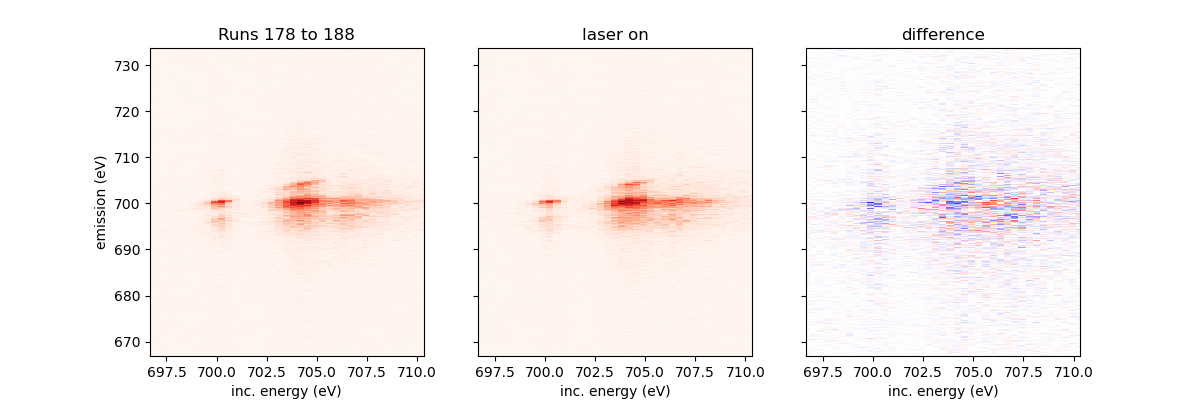

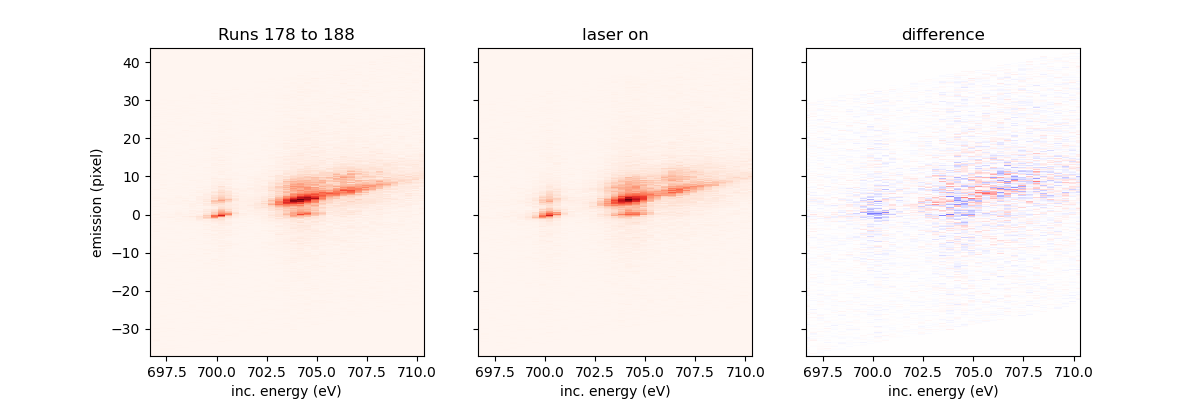

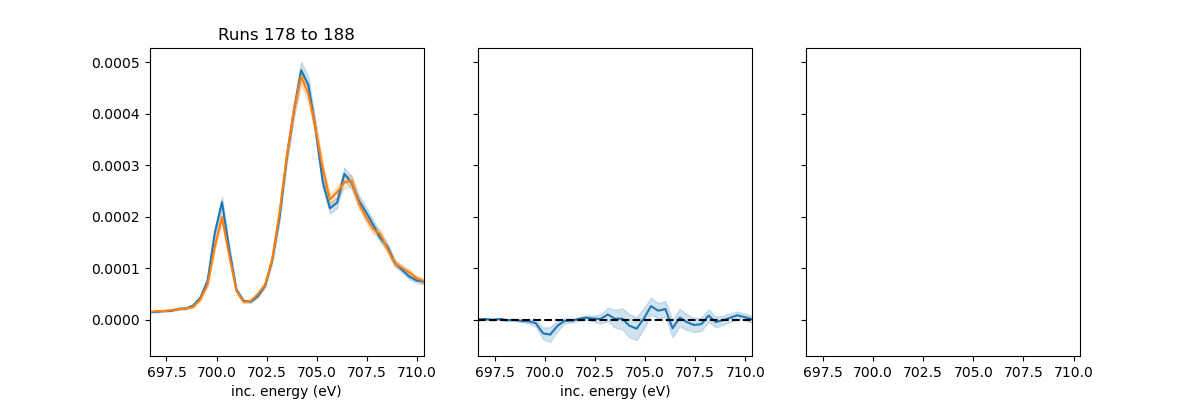

In [7]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'

bgrun = 86
# runs=[112,114,115,116,117,118,119,120,121,122,123,127,129,]
# runs = [138,139,140,141,145]
# runs = [112,114,115,116,117,118,119,120,121,122,123,127,129,138,139,140,141,145]

runs = [178,179,180,181,182,183,184,185,186,188]

exp = 'rix101231825'


fyaml = '../roi_input.yml'

bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
bgyaml = '../BGroi_input.yml'

avg = Average(runs, proc_path = 'proc/Run', avg = 'mean', output_path = f'avg/{runs[0]}_to_{runs[-1]}.h5',
             raw_path = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run' , bgpath = bgname, fyaml=fyaml, bgyaml=bgyaml, 
             save= True,norm = True)

avg.plot_svls2D(figsize=(12,4),savefig=True)
avg.plot_svls2D_ET(figsize=(12,4),savefig=False)
avg.plot_svls1D(figsize=(12,4))


In [15]:
try:
    emi = avg.get_emi()
    print(f'emi axis: [{emi.min():.2f}, {emi.max():.2f}] eV, n={len(emi)}')
except Exception as e:
    print(f'get_emi failed: {type(e).__name__}: {e}')
print(f'runs = {avg.runs}')
print(f'emi_calib rows = {avg.yaml["emi_calib"]}')

[9.333333e-02 6.627667e+02]
emi axis: [662.77, 736.97] eV, n=796
runs = [114]
emi_calib rows = [[1, 84, 0.09545455, 662.2045], [87, 145, 0.09333333, 662.7667], [147, 188, 0.08571429, 666.2429], [194, 252, 0.08571429, 666.4143]]
